In [3]:
%load_ext autoreload
%autoreload 2

from helper import fitting, models, plot
from matplotlib import pyplot as plt
from alive_progress import alive_bar
import numpy as np
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# ---- Loading data ----
import sys

if sys.platform == "win32": # windows
    depth_df = pd.read_csv(r'C:\Users\t139116uhn\OneDrive - UHN\vis_test (caprese) results\vis_x.csv', dtype = float)
    time_df = pd.read_csv(r'C:\Users\t139116uhn\OneDrive - UHN\vis_test (caprese) results\vis_time.csv', dtype = float)
    conc_df = pd.read_csv(r'C:\Users\t139116uhn\OneDrive - UHN\vis_test (caprese) results\vis_conc_xt.csv', dtype = float)

elif sys.platform == "darwin": # mac
    depth_df = pd.read_csv('/Users/isaac/Library/CloudStorage/OneDrive-UHN/vis_test (caprese) results/vis_x.csv', dtype = float)
    time_df = pd.read_csv('/Users/isaac/Library/CloudStorage/OneDrive-UHN/vis_test (caprese) results/vis_time.csv', dtype = float)
    conc_df = pd.read_csv('/Users/isaac/Library/CloudStorage/OneDrive-UHN/vis_test (caprese) results/vis_conc_xt.csv', dtype = float)

In [5]:
# convert to np arrayx
depth = np.asarray(depth_df, dtype = float).flatten()
time = np.asarray(time_df, dtype = float).flatten()
conc = np.asarray(conc_df, dtype = float)

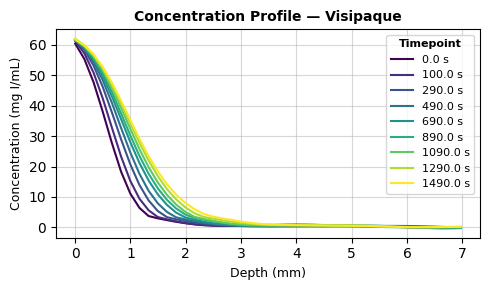

In [6]:
# ---- Experimental concentration profiles at the beginning, middle, and end of the experiment ----
profs = range(0, len(time), 10)
n_profs = len(profs)
cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, n_profs))

fig, ax = plt.subplots(figsize = (5, 3))
j = 0
for i in profs:
    ax.plot(depth, conc[i, :], label = f"{time[i]} s", color = colors[j])
    j += 1
ax.legend(title = "Timepoint", fontsize = 8, 
          title_fontproperties = {"weight": "bold", "size": 8})
ax.set_ylabel("Concentration (mg I/mL)", size = 9)
ax.set_xlabel("Depth (mm)", size = 9)
ax.grid(alpha = 0.5)
ax.set_title(f"Concentration Profile — Visipaque", 
             fontdict = {"weight": "bold", "size": 10})
plt.tight_layout()
plt.show()

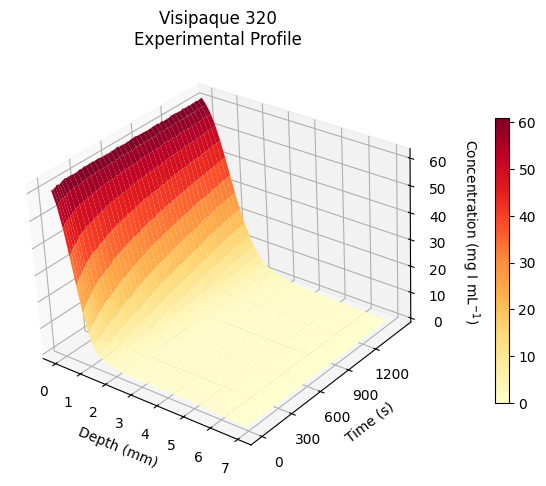

In [7]:
fig, ax = plt.subplots(1, 1, subplot_kw = {"projection": "3d"}, figsize = (6, 6), squeeze = False)
ax = ax.flatten()

depth_mesh, time_mesh = np.meshgrid(depth, time)

plot.plot_prof(fig, ax, 0, x = depth_mesh, y = time_mesh, z = conc, 
          name = "Visipaque 320\nExperimental Profile", 
          elem = "I")
plt.tight_layout()
plt.show()

In [8]:
first_row = conc[:, 0]
cs_experimental = np.nanmean(first_row)

configs = []

for model in fitting.MODEL_REGISTRY:
    for fit_x0 in [False, True]:
        for cs_mode in fitting.VALID_CS_MODES:
            for d_mode in fitting.VALID_D_MODES:
                cfg = fitting.FitConfig(
                    model = model,
                    fit_x0 = fit_x0,
                    d_mode = d_mode,
                    cs_mode = cs_mode,
                    cs_fixed = cs_experimental if cs_mode == "fixed" else None
                )
                configs.append(cfg)

print(f"Total configs: {len(configs)}")

Total configs: 24


In [9]:
results = []

with alive_bar(len(configs), title = "Fitting configs", force_tty = True) as bar:
    for cfg in configs:
        result = fitting.fit_diffusion(conc, depth, time, cfg)
        results.append(result)
        bar()

Fitting configs |████████████████████████████████████████| 24/24 [100%] in 18.7s


In [10]:
rows = []

for r in results:
    cfg = r.config
    d_summary = r.d_global if cfg.d_mode == "global" else np.nanmean(r.d_per_t)
    rows.append({
        "model": cfg.model,
        "fit_x0": cfg.fit_x0,
        "d_mode": cfg.d_mode,
        "cs_mode": cfg.cs_mode,
        "D": d_summary,
        "R2": r.r2_global,
        "RMSE_mean": np.nanmean(r.rmse_per_t) if r.rmse_per_t is not None else np.nan,
        "AIC": r.aic,
        "BIC": r.bic,
        "n_params": r.n_params_total
    })

summary_df = pd.DataFrame(rows)
summary_df["delta_aic"] = summary_df["AIC"] - summary_df["AIC"].min()
summary_df.sort_values("delta_aic")
summary_df

,model,fit_x0,d_mode,cs_mode,D,R2,RMSE_mean,AIC,BIC,n_params,delta_aic
0,semi-infinite,False,per-timepoint,per-timepoint,0.002223,0.989759,1.821558,4298.077186,5280.993466,160,7.115949e+03
1,semi-infinite,False,global,per-timepoint,0.001083,0.930455,3.768135,10224.666684,10722.268051,81,1.304254e+04
2,semi-infinite,False,per-timepoint,global,0.002162,0.989648,1.830715,4170.547300,4668.148667,81,6.988419e+03
3,semi-infinite,False,global,global,0.001022,0.921674,3.989724,10470.236599,10482.523052,2,1.328811e+04
4,semi-infinite,False,per-timepoint,fixed,0.002505,0.982220,2.374087,6065.731049,6557.189189,80,8.883603e+03
5,semi-infinite,False,global,fixed,0.001159,0.917317,4.250833,10710.128448,10716.271675,1,1.352800e+04
6,semi-infinite,True,per-timepoint,per-timepoint,0.000697,0.998704,0.651509,-2693.384597,-1219.010177,240,1.244869e+02
7,semi-infinite,True,global,per-timepoint,0.000925,0.955373,3.009666,8827.851328,9816.910835,161,1.164572e+04
8,semi-infinite,True,per-timepoint,global,0.000709,0.998692,0.654606,-2817.871527,-1828.812020,161,3.878527e-07
9,semi-infinite,True,global,global,0.000232,0.984204,1.798236,5110.748633,5614.493227,82,7.928620e+03


In [11]:
target_configs = [cfg for cfg in configs if (cfg.d_mode == "per-timepoint" and cfg.cs_mode in ["global", "fixed"] and cfg.fit_x0 == True)]

d_per_t = []
cs_global = []
x0_per_t = []

for r in results:
    if r.config in target_configs:
        d_per_t.append(r.d_per_t)
        x0_per_t.append(r.x0_per_t)
        if r.config.model == "infinite":
            cs_global.append(r.cs_global * 0.5)
        else:
            cs_global.append(r.cs_global)

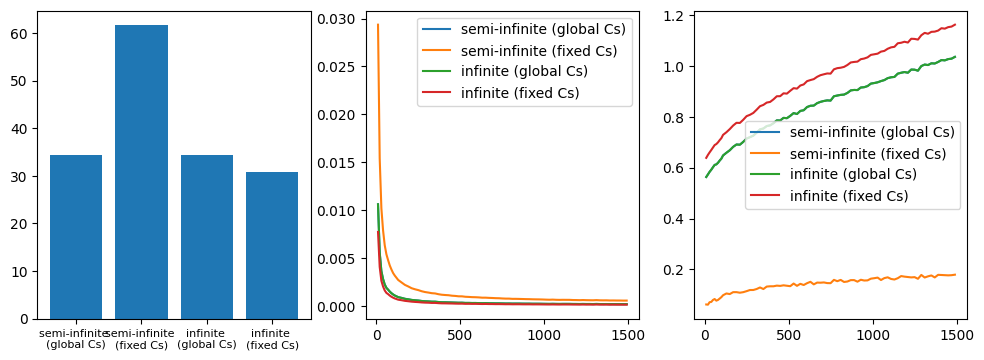

In [34]:
to_plot = zip(target_configs, d_per_t, x0_per_t)

fig, ax = plt.subplots(1, 3, figsize = (12, 4))
cs = ax[0]
d = ax[1]
x0 = ax[2]

labs = [f"{cfg.model} \n({cfg.cs_mode} Cs)" for cfg in target_configs]
cs.bar(labs, cs_global)
cs.tick_params(axis = "x", labelsize = 8)

for cfg, d_cfg, x0_cfg in to_plot:
    label = f"{cfg.model} ({cfg.cs_mode} Cs)"
    d.plot(time, d_cfg, label = label)
    x0.plot(time, x0_cfg, label = label)

d.legend()
x0.legend()
plt.show()

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (2,) and arg 1 with shape (4,).

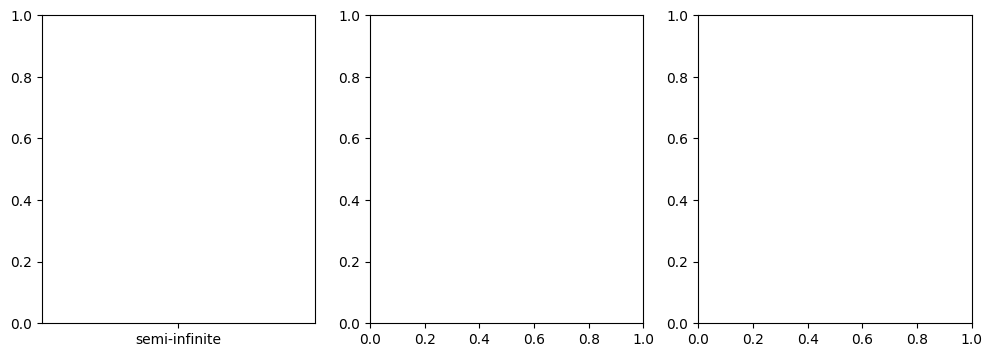

In [13]:
fig, ax = plt.subplots(1, 3, figsize = (12, 4))

cs = ax[0]
d = ax[1]
x0 = ax[2]

cs.bar(["semi-infinite", "infinite"], cs_global)

d.plot(time, d_per_t[0], label = "semi-infinite")
d.plot(time, d_per_t[1], label = "infinite")
d.legend()

x0.plot(time, x0_per_t[0], label = "semi-infinite")
x0.plot(time, x0_per_t[1], label = "infinite")
x0.legend()

plt.show()